# eval figure layout test

tests `_create_aggregate_eval_figure` using scroll masks as stand-in predictions.
no model needed. verifies 4-row × 2-col layout, depth labels, and aspect ratio handling
for portrait (small scroll) vs landscape (large scroll) geometries.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import cv2

TILE = 32

# standalone copy of _create_aggregate_eval_figure — no class needed
def create_aggregate_eval_figure(all_pred_data, train_split_w, label_binary=None):
    """n_blocks-row x 2-col figure.  left col = prediction, right col = overlay."""
    n_blocks = len(all_pred_data)
    if n_blocks == 0:
        return None

    sample_pred = all_pred_data[0][0]
    h_tiles, w_tiles = sample_pred.shape
    aspect = w_tiles / max(h_tiles, 1)

    panel_w = max(6.0, min(16.0, w_tiles * 0.06))
    panel_h = max(2.0, min(12.0, panel_w / aspect))
    panel_w = panel_h * aspect          # recompute after possible h clamp

    fig_w = panel_w * 2 + 0.3
    fig_h = panel_h * n_blocks + 0.4

    fig, axes = plt.subplots(n_blocks, 2, figsize=(fig_w, fig_h), squeeze=False)
    split_pos = train_split_w - 0.5

    for row, (full_pred, train_pred, d_start, d_end) in enumerate(all_pred_data):
        ax_pred = axes[row, 0]
        ax_pred.imshow(full_pred, cmap='inferno', vmin=0, vmax=1, aspect='equal')
        ax_pred.set_title(f'Depth {d_start}-{d_end}', fontsize=8)
        ax_pred.axvline(x=split_pos, color='red', linestyle='--', linewidth=0.8)
        ax_pred.axis('off')

        ax_ov = axes[row, 1]
        ax_ov.imshow(full_pred, cmap='inferno', vmin=0, vmax=1, aspect='equal')
        ax_ov.set_title(f'Overlay {d_start}-{d_end}', fontsize=8)
        if label_binary is not None:
            ov = np.zeros((*full_pred.shape, 4), dtype=np.float32)
            h = min(label_binary.shape[0], ov.shape[0])
            w = min(label_binary.shape[1], ov.shape[1])
            ov[:h, :w][label_binary[:h, :w] > 0.5] = [1, 1, 1, 0.4]
            ax_ov.imshow(ov)
        ax_ov.axvline(x=split_pos, color='red', linestyle='--', linewidth=0.8)
        ax_ov.axis('off')

    plt.subplots_adjust(wspace=0.04, hspace=0.12,
                        left=0.01, right=0.99,
                        top=0.98, bottom=0.01)
    return fig


def mask_to_tiled(mask_path, y0, y1, x0, x1, tile=TILE):
    """load mask, crop, block-average to tile resolution, return float32 [0,1]"""
    raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    assert raw is not None, f"could not read {mask_path}"
    crop = raw[y0:y1, x0:x1].astype(np.float32) / 255.0
    h_t = (y1 - y0) // tile
    w_t = (x1 - x0) // tile
    # reshape to (h_t, tile, w_t, tile) then average over tile dimensions
    tiled = crop[:h_t*tile, :w_t*tile].reshape(h_t, tile, w_t, tile).mean(axis=(1, 3))
    return tiled.astype(np.float32)


def make_pred_data(base_map, depth_windows, train_frac=0.75):
    """build all_pred_data list from a tiled base map with slight per-depth variation"""
    rng = np.random.default_rng(42)
    w_t = base_map.shape[1]
    train_w = int(w_t * train_frac)
    all_pred_data = []
    for d_start, d_end, scale in depth_windows:
        pred = np.clip(base_map * scale + rng.normal(0, 0.03, base_map.shape), 0, 1).astype(np.float32)
        train_pred = pred[:, :train_w]
        all_pred_data.append((pred, train_pred, d_start, d_end))
    return all_pred_data, train_w


# depth windows simulating d_start=28 d_end=48 with depth=8 and z_step=4
DEPTH_WINDOWS = [
    (28, 36, 0.50),   # below peak — dimmer
    (32, 40, 0.90),   # peak window
    (36, 44, 0.70),
    (40, 48, 0.40),   # above peak — dimmer
]

print("helpers ready")

helpers ready


## load scroll masks

small scroll mask shape: (9163, 5048)  (H x W px)
large scroll mask shape: (13513, 17381)  (H x W px)


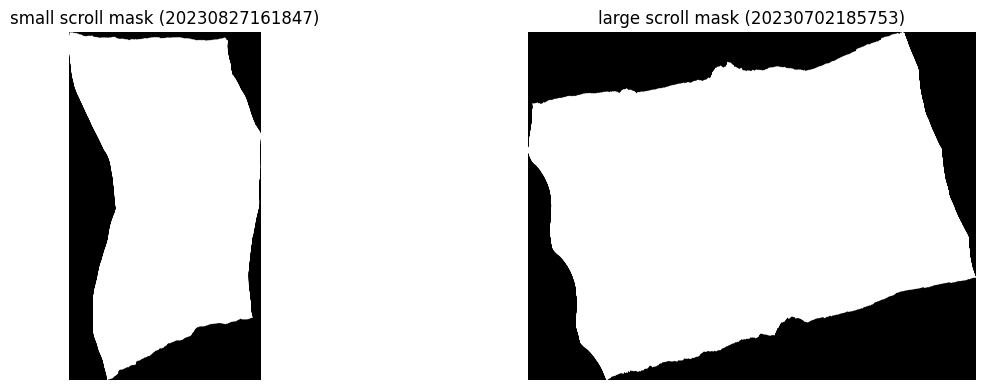

In [2]:
SMALL_MASK = "./masks/20230827161847.png"
LARGE_MASK = "./masks/20230702185753.png"

small_raw = cv2.imread(SMALL_MASK, cv2.IMREAD_GRAYSCALE)
large_raw = cv2.imread(LARGE_MASK, cv2.IMREAD_GRAYSCALE)

print(f"small scroll mask shape: {small_raw.shape}  (H x W px)")
print(f"large scroll mask shape: {large_raw.shape}  (H x W px)")

# quick preview of raw masks
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
a1.imshow(small_raw, cmap='gray'); a1.set_title("small scroll mask (20230827161847)"); a1.axis('off')
a2.imshow(large_raw, cmap='gray'); a2.set_title("large scroll mask (20230702185753)"); a2.axis('off')
plt.tight_layout()
plt.show()

## synthesize dummy prediction maps

small scroll eval region: y 200-5600, x 1000-4600 (same as training visualizer)
→ 168 × 112 tiles — portrait aspect (~0.67)

large scroll: FULL mask extent 13513×17381 px
→ 422 × 543 tiles — mildly landscape aspect (~1.29)
no extra downscaling; block-average to tile resolution is the same step the real visualizer uses

In [ ]:
# SMALL SCROLL — eval region matches visualizer crop
small_base = mask_to_tiled(SMALL_MASK, y0=200, y1=5600, x0=1000, x1=4600)
small_label = (small_base > 0.5).astype(bool)
small_preds, small_train_w = make_pred_data(small_base, DEPTH_WINDOWS)

h_s, w_s = small_base.shape
print(f"small scroll tile map: {h_s} h × {w_s} w tiles  aspect={w_s/h_s:.2f}")

# LARGE SCROLL — full mask, no spatial crop
# 13513 × 17381 px → 422 × 543 tiles at tile_size=32
large_base = mask_to_tiled(LARGE_MASK, y0=0, y1=large_raw.shape[0], x0=0, x1=large_raw.shape[1])
large_label = (large_base > 0.5).astype(bool)
large_preds, large_train_w = make_pred_data(large_base, DEPTH_WINDOWS)

h_l, w_l = large_base.shape
print(f"large scroll tile map: {h_l} h × {w_l} w tiles  aspect={w_l/h_l:.2f}")
print(f"(no extra downscaling — block-average to tile resolution is identical to what the visualizer does)")

small scroll tile map: 168 h × 112 w tiles  aspect=0.67
train split width: 84 tiles
large scroll tile map: 200 h × 400 w tiles  aspect=2.00
train split width: 300 tiles


## small scroll eval figure (portrait, ~0.67 aspect)

layout check passed: 4 rows x 2 cols, all depth labels present
small scroll figsize: 13.74 w × 40.72 h inches


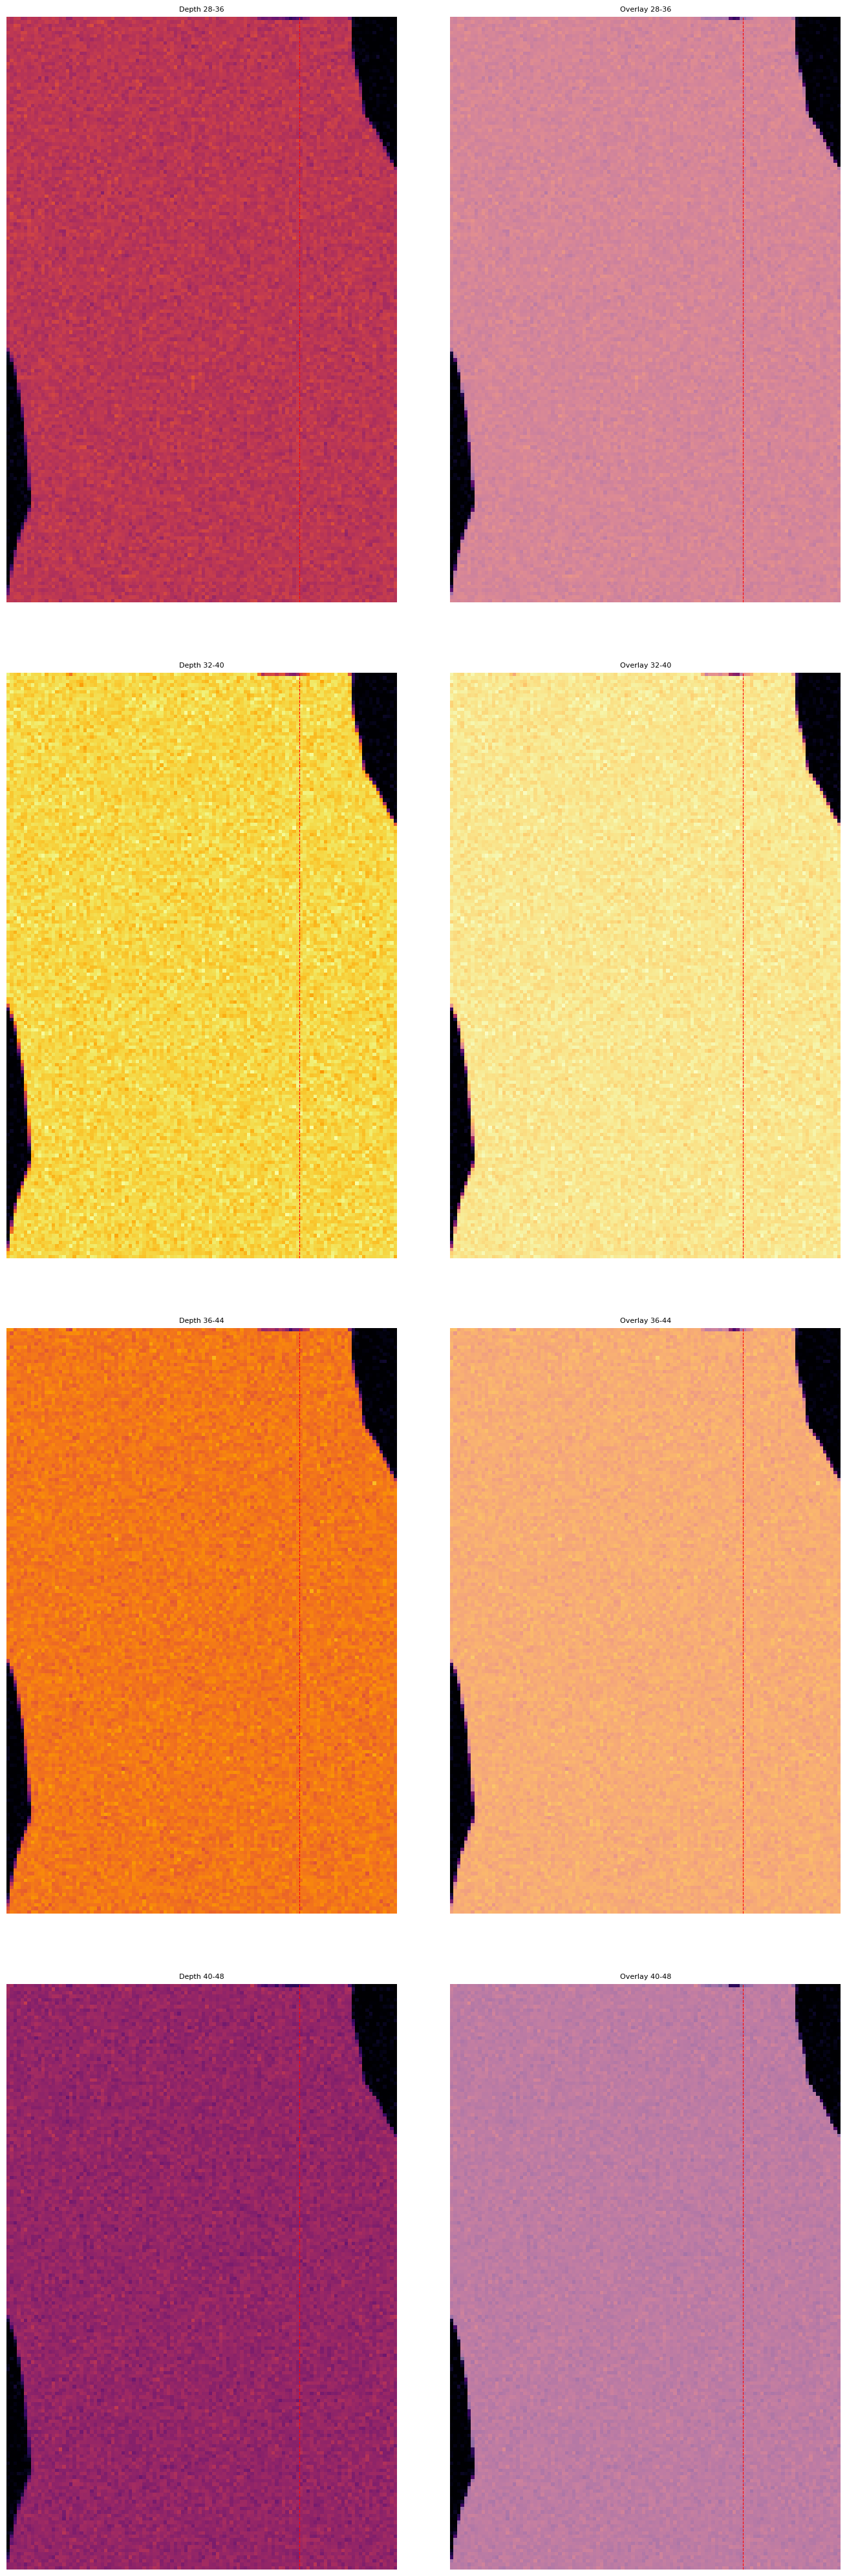

In [4]:
fig_small = create_aggregate_eval_figure(small_preds, small_train_w, small_label)

# verify layout: 4 rows × 2 cols, each titled with depth range
axes_small = fig_small.get_axes()
assert len(axes_small) == 8, f"expected 8 axes, got {len(axes_small)}"
for i, (_, _, d_start, d_end) in enumerate(small_preds):
    assert f"{d_start}-{d_end}" in axes_small[i*2].get_title(), "depth label missing from pred axis"
    assert f"{d_start}-{d_end}" in axes_small[i*2+1].get_title(), "depth label missing from overlay axis"
print("layout check passed: 4 rows x 2 cols, all depth labels present")

w_in, h_in = fig_small.get_size_inches()
print(f"small scroll figsize: {w_in:.2f} w × {h_in:.2f} h inches")
plt.show()

## large scroll eval figure (landscape, ~2.0 aspect)

layout check passed: 4 rows x 2 cols
large scroll figsize: 32.30 w × 32.40 h inches


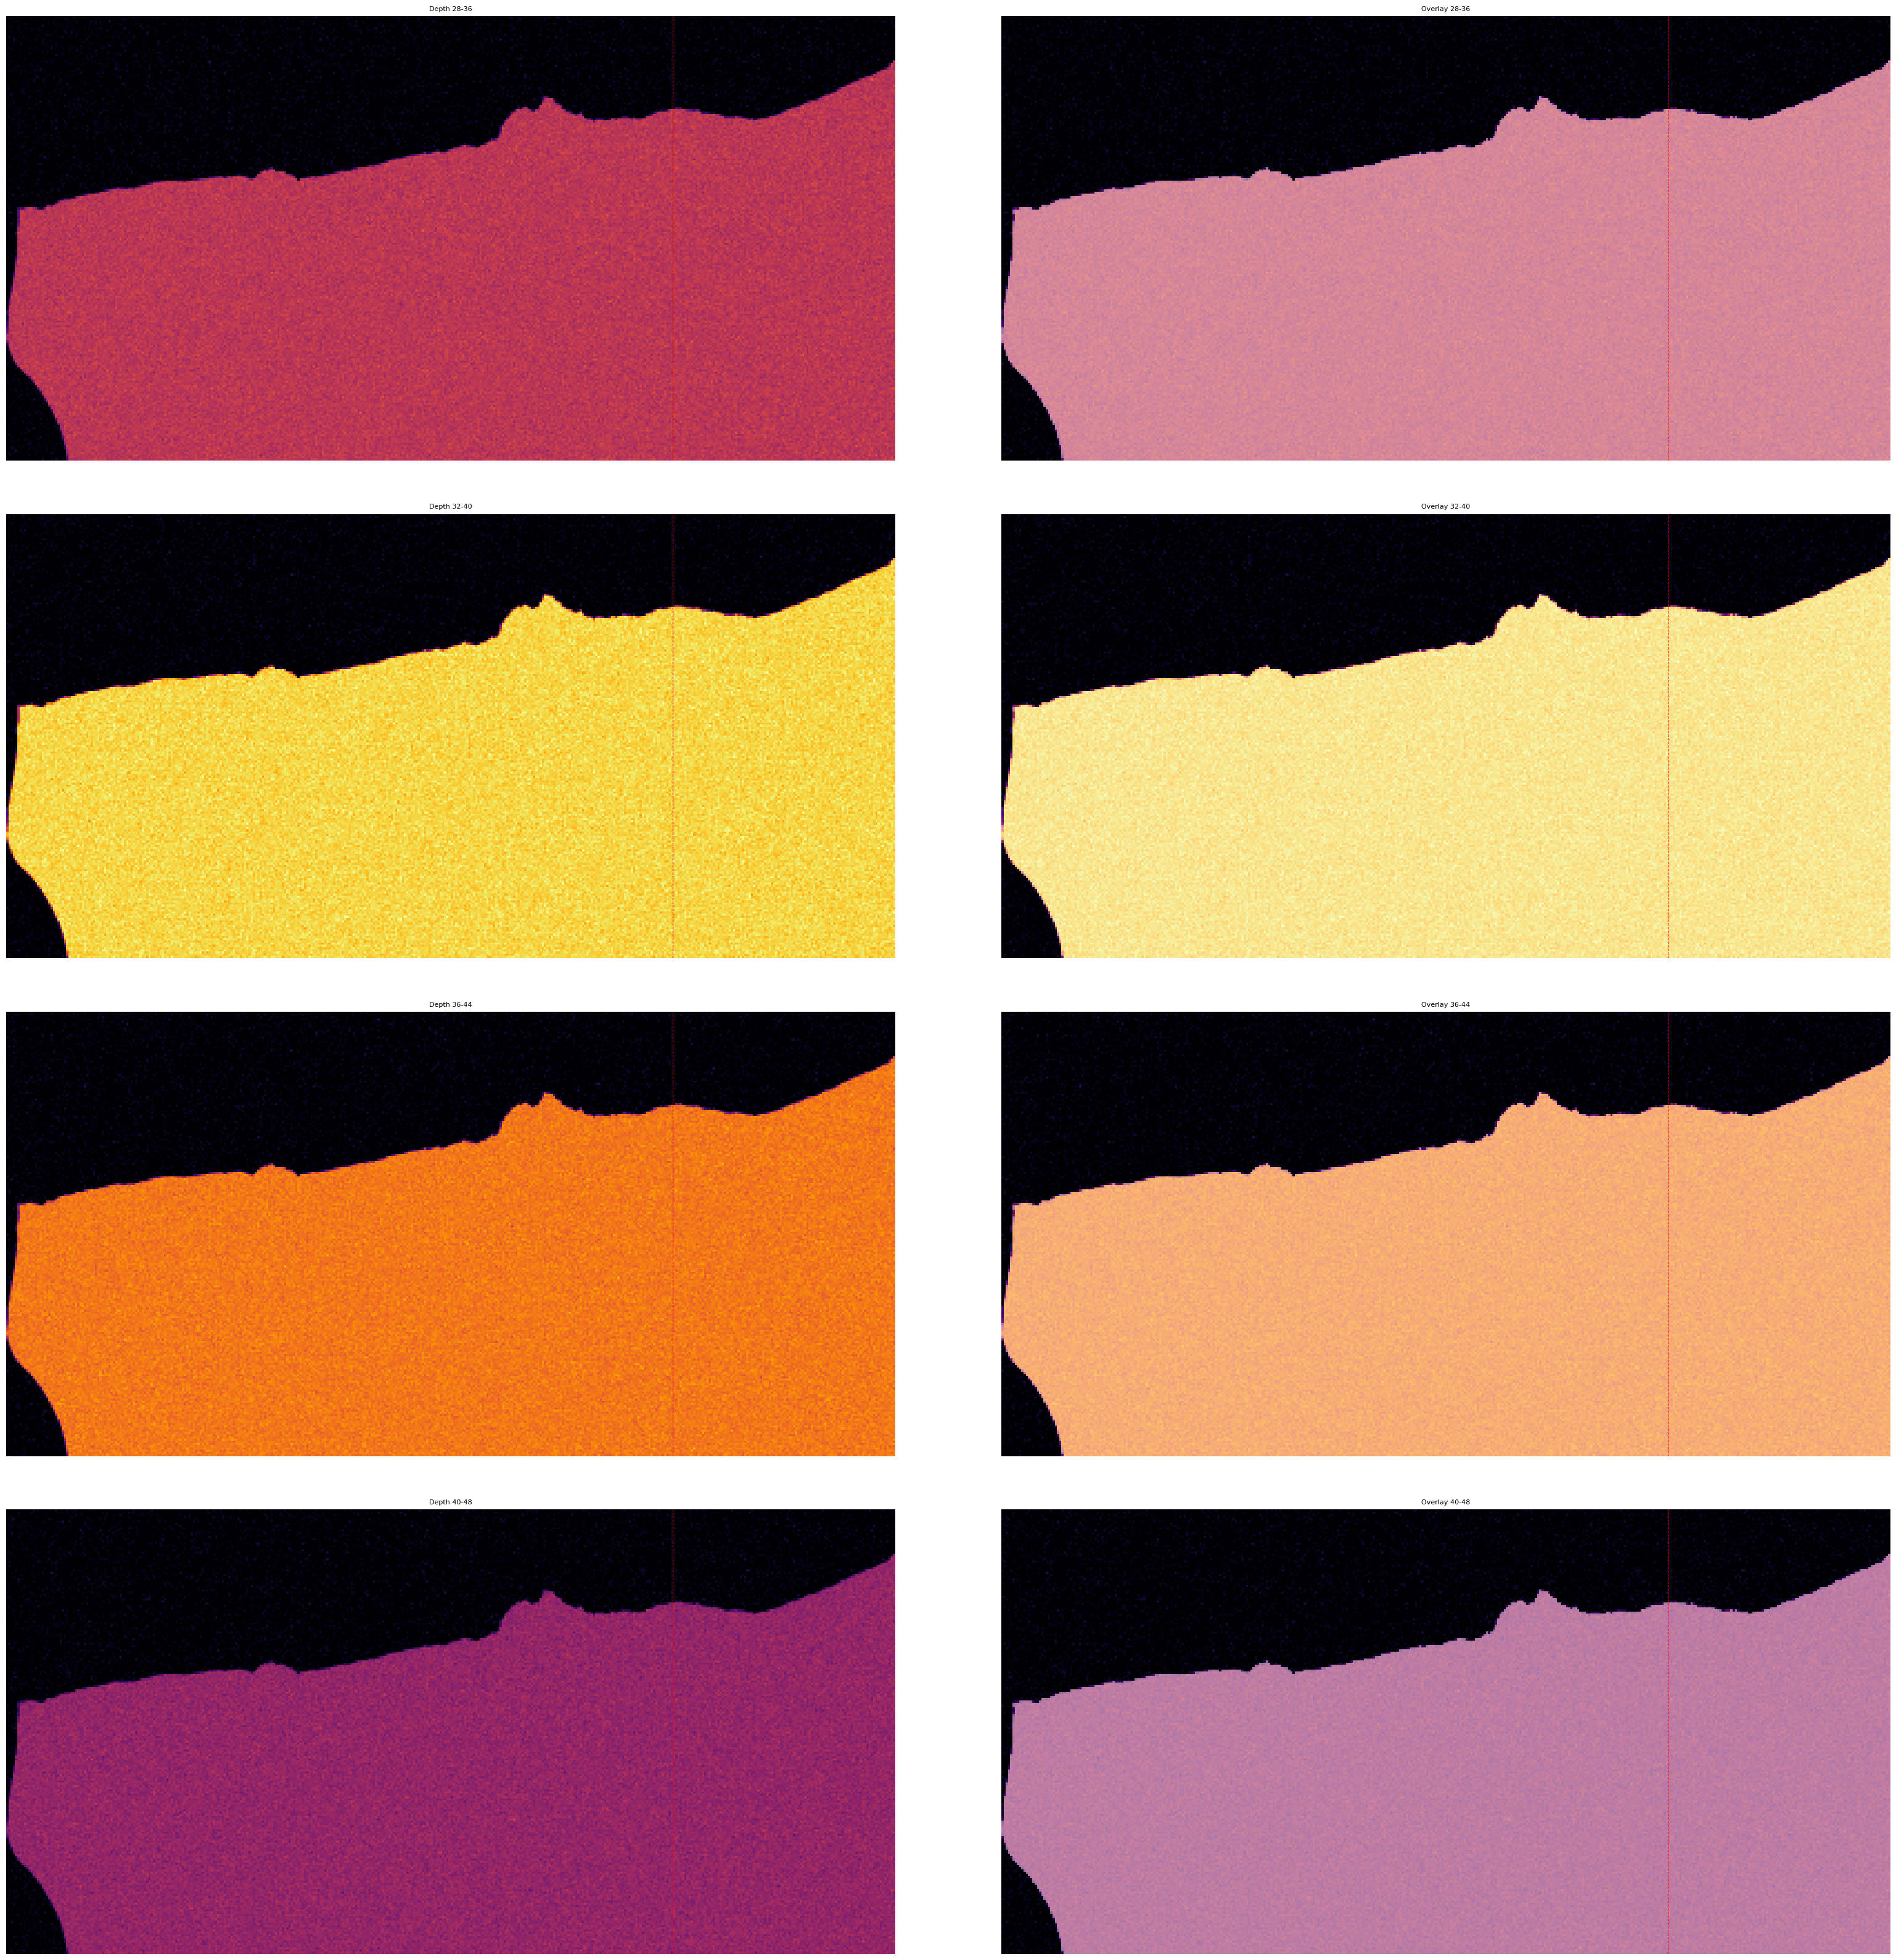

In [5]:
fig_large = create_aggregate_eval_figure(large_preds, large_train_w, large_label)

axes_large = fig_large.get_axes()
assert len(axes_large) == 8, f"expected 8 axes, got {len(axes_large)}"
print("layout check passed: 4 rows x 2 cols")

w_in_l, h_in_l = fig_large.get_size_inches()
print(f"large scroll figsize: {w_in_l:.2f} w × {h_in_l:.2f} h inches")
plt.show()

## side-by-side aspect ratio comparison

In [6]:
def compute_panel_dims(h_tiles, w_tiles):
    """same formula as _create_aggregate_eval_figure"""
    aspect = w_tiles / max(h_tiles, 1)
    panel_w = max(6.0, min(16.0, w_tiles * 0.06))
    panel_h = max(2.0, min(12.0, panel_w / aspect))
    panel_w = panel_h * aspect
    fig_w = panel_w * 2 + 0.3
    fig_h = panel_h * 4 + 0.4      # 4 depth blocks
    return aspect, panel_w, panel_h, fig_w, fig_h

s_asp, s_pw, s_ph, s_fw, s_fh = compute_panel_dims(h_s, w_s)
l_asp, l_pw, l_ph, l_fw, l_fh = compute_panel_dims(h_l, w_l)

print("SMALL SCROLL (portrait)")
print(f"  tile map    : {h_s} h x {w_s} w")
print(f"  aspect      : {s_asp:.3f}  (w/h)")
print(f"  panel       : {s_pw:.2f} w × {s_ph:.2f} h inches")
print(f"  full figure : {s_fw:.2f} w × {s_fh:.2f} h inches")
print()
print("LARGE SCROLL (landscape)")
print(f"  tile map    : {h_l} h x {w_l} w")
print(f"  aspect      : {l_asp:.3f}  (w/h)")
print(f"  panel       : {l_pw:.2f} w × {l_ph:.2f} h inches")
print(f"  full figure : {l_fw:.2f} w × {l_fh:.2f} h inches")
print()
print(f"width ratio large/small: {l_fw/s_fw:.2f}x")
print(f"height ratio large/small: {l_fh/s_fh:.2f}x  (landscape rows are shorter)")

SMALL SCROLL (portrait)
  tile map    : 168 h x 112 w
  aspect      : 0.667  (w/h)
  panel       : 6.72 w × 10.08 h inches
  full figure : 13.74 w × 40.72 h inches

LARGE SCROLL (landscape)
  tile map    : 200 h x 400 w
  aspect      : 2.000  (w/h)
  panel       : 16.00 w × 8.00 h inches
  full figure : 32.30 w × 32.40 h inches

width ratio large/small: 2.35x
height ratio large/small: 0.80x  (landscape rows are shorter)
